# LeetCode #203: Remove Linked List Elements

https://leetcode.com/problems/remove-linked-list-elements/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Recursive** | $O(n)$ | $O(n)$ call stack |
| **Optimal: Sentinel/Dummy Node** | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Recursive
Recursively process the rest of the list. If the current node's value equals `val`, return the result of processing `next` (skipping current). Otherwise, set `curr.next` to the recursive result and return `curr`. Uses $O(n)$ stack space.

### Optimal: Sentinel/Dummy Node ★
Create a dummy node pointing to `head`. Use a `prev` pointer starting at the dummy. Walk through the list:
- If `curr.val == val`, skip it: `prev.next = curr.next`.
- Otherwise, advance `prev = curr`.
- Always advance `curr = curr.next`.

Return `dummy.next` as the new head.

**Why use a dummy node:** It elegantly handles the case where the head itself needs to be removed, avoiding special-case logic.

**Constraints:**
* `0 <= n <= 10^4`
* `1 <= Node.val <= 50`

## Solutions

### C#

In [ ]:
public class Solution {
    public ListNode RemoveElements(ListNode head, int val) {
        var dummy = new ListNode(0, head);
        var prev = dummy;
        var curr = head;
        
        while (curr != null) {
            if (curr.val == val) {
                prev.next = curr.next;
            } else {
                prev = curr;
            }
            curr = curr.next;
        }
        
        return dummy.next;
    }
}

### Python

In [ ]:
class Solution:
    def removeElements(self, head, val):
        dummy = ListNode(0, head)
        prev = dummy
        curr = head
        
        while curr:
            if curr.val == val:
                prev.next = curr.next
            else:
                prev = curr
            curr = curr.next
        
        return dummy.next

### Go

In [ ]:
func removeElements(head *ListNode, val int) *ListNode {
    dummy := &ListNode{Next: head}
    prev := dummy
    curr := head
    
    for curr != nil {
        if curr.Val == val {
            prev.Next = curr.Next
        } else {
            prev = curr
        }
        curr = curr.Next
    }
    
    return dummy.Next
}

### Rust

In [ ]:
impl Solution {
    pub fn remove_elements(
        head: Option<Box<ListNode>>,
        val: i32,
    ) -> Option<Box<ListNode>> {
        let mut dummy = Box::new(ListNode { val: 0, next: head });
        let mut curr = &mut dummy;
        
        while curr.next.is_some() {
            if curr.next.as_ref().unwrap().val == val {
                let next = curr.next.as_mut().unwrap().next.take();
                curr.next = next;
            } else {
                curr = curr.next.as_mut().unwrap();
            }
        }
        
        dummy.next
    }
}

## Example Scenarios

1. **Common Case — Remove from Middle:** `head = [1,2,6,3,4,5,6]`, `val = 6` → `[1,2,3,4,5]`. Walk with a dummy node; skip both 6s (positions 2 and 6) by setting `prev.next = curr.next`. WHY tricky: Multiple occurrences scattered throughout — the algorithm handles each independently without losing track of `prev`.

2. **Slightly Complex — All Nodes Removed:** `head = [7,7,7,7]`, `val = 7` → `[]`. Every node matches. The dummy's next eventually becomes null. WHY tricky: The head itself must be removed repeatedly — this is the primary reason for the sentinel/dummy node pattern. Without it, you need a separate while loop for head removal.

3. **Edge Case — Time Factor (Maximum Length):** `head = [1,2,3,...,10000]` ($n = 10^4$ nodes), `val = 5000` → `[1,...,4999,5001,...,10000]`. Only one node removed from the middle of a max-length list. The algorithm traverses all $10^4$ nodes exactly once. WHY tricky: Worst-case time is always $O(n)$ regardless of how many nodes match — every node must be visited. The single pass is optimal.

4. **Edge Case — Space Factor (Empty List):** `head = []`, `val = 1` → `[]`. Head is null. The dummy node is created but the while loop body never executes. Return `dummy.next = \text{null}$. WHY tricky: The dummy node pattern handles empty lists naturally — no null checks needed. Only 1 extra node allocated: $S(n) = O(1)$.

5. **Almost-Impossible — Consecutive Removals at Head and Tail:** `head = [50,50,1,2,3,50,50]`, `val = 50` → `[1,2,3]`. Nodes with $val = 50$ (max constraint value) at both ends. The dummy handles head removals; tail removals set `prev.next = \text{null}$. WHY tricky: Combines head and tail removal in one test. Without a dummy node, removing consecutive head nodes requires special-case logic before the main traversal.

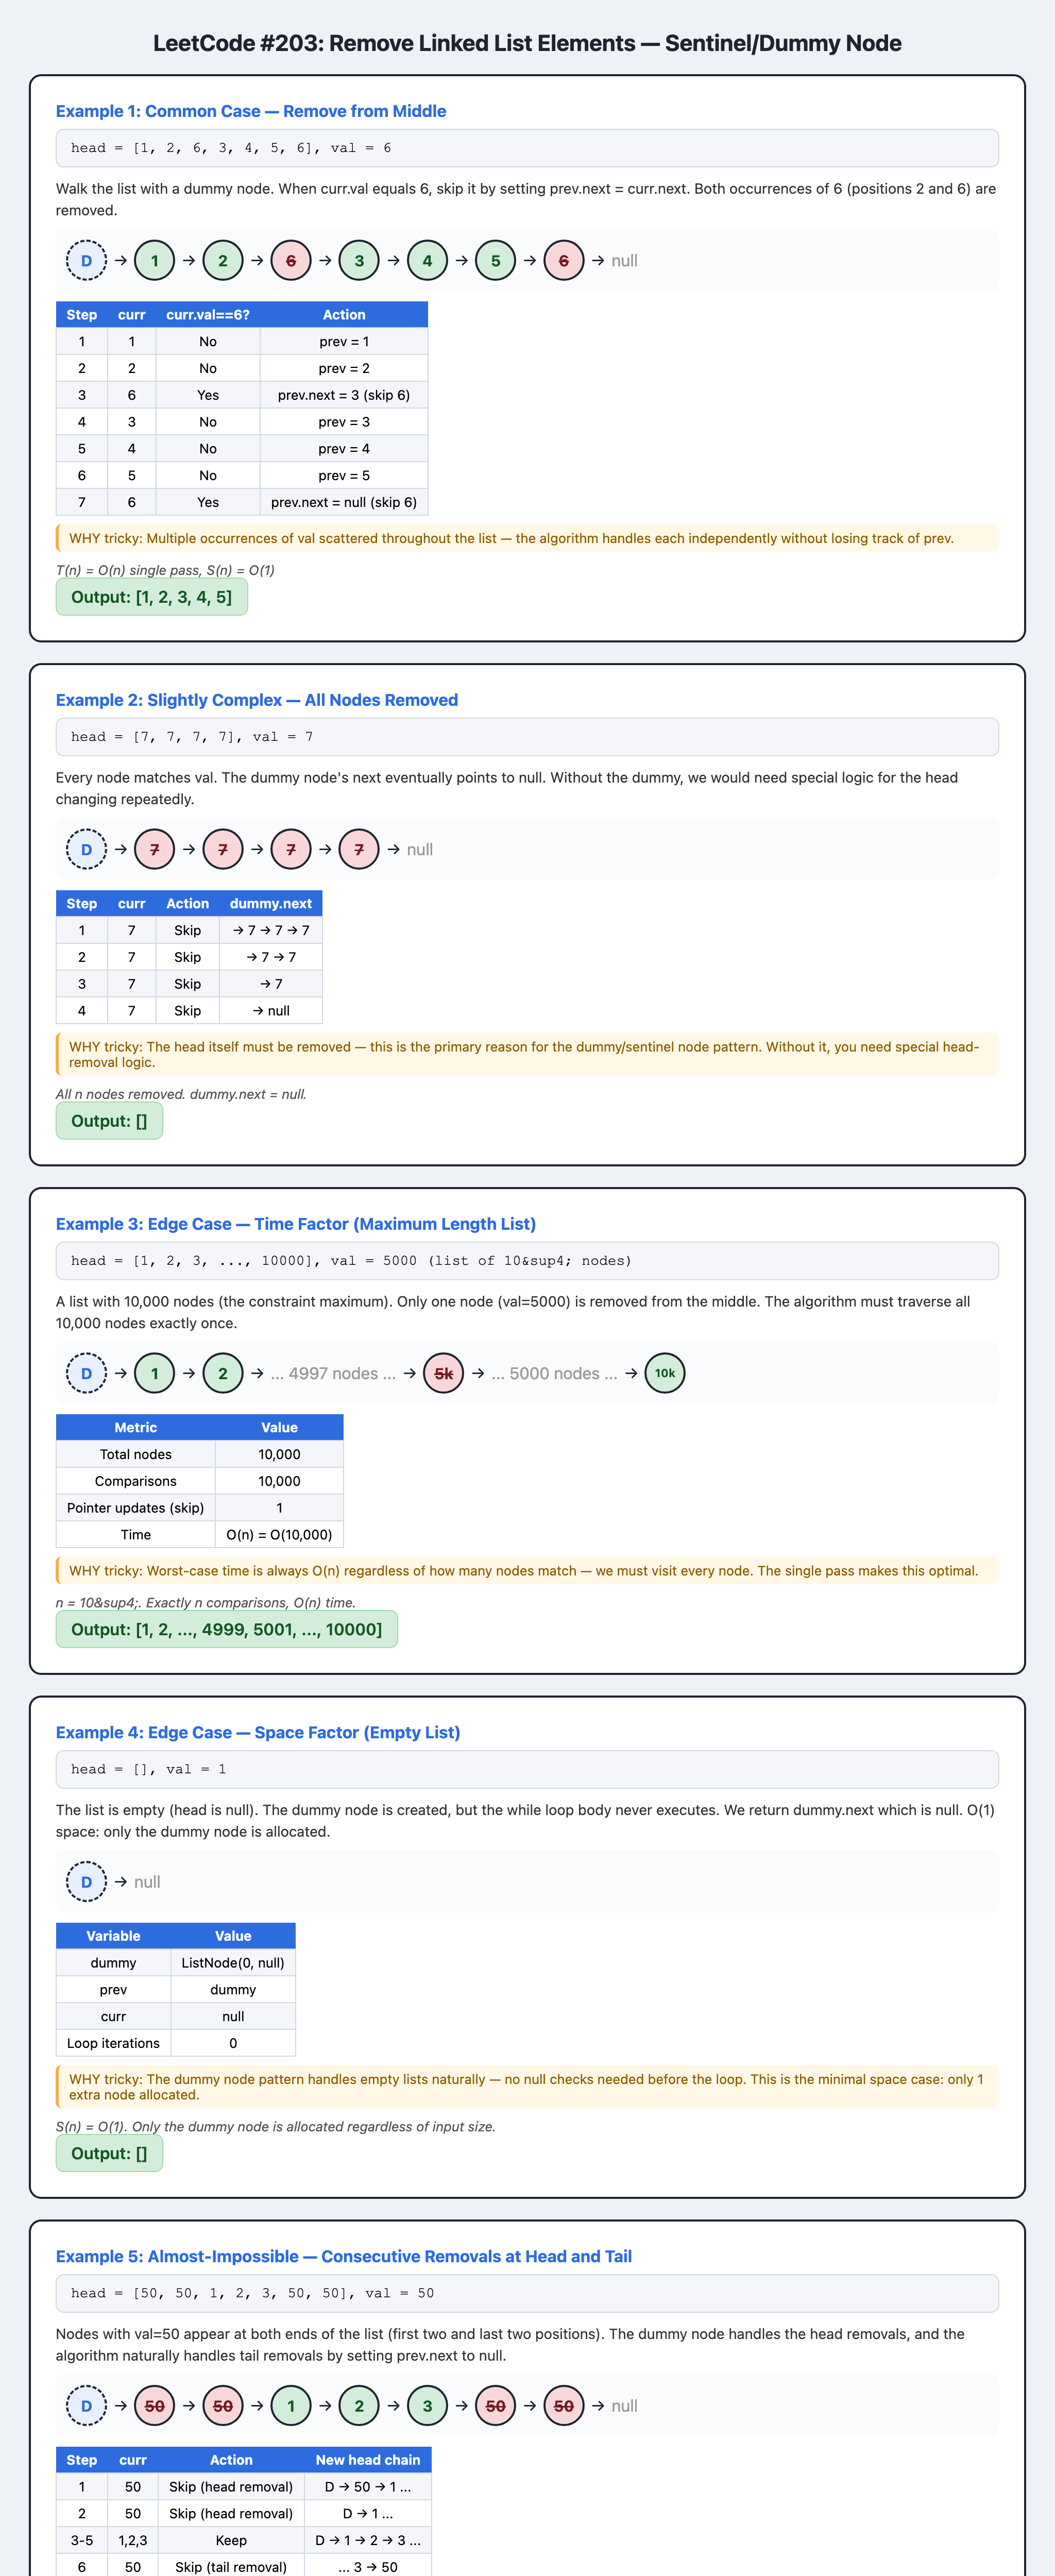